# Visual Statevector Tests

## Visualizing the Statevector
**Objective:** Extract and visualize the exact mathematical state of the Bell State *before* measurement.

**Theory:**
A quantum state is represented by a vector of complex numbers. Instead of running a simulator 1,000 times to guess the probabilities, we can calculate the exact mathematical state. 
*Note:* To get a pure Statevector, we **must not** add measurement gates. Measurement collapses the state!

In [9]:
# Install dependencies if needed: !pip install qiskit qiskit-aer matplotlib pylatexenc
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere, plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

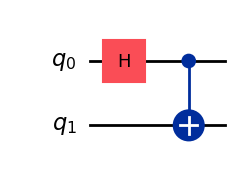

In [10]:
# 1. Initialize a 2-qubit circuit (0 classical bits, because we aren't measuring!)
qc = QuantumCircuit(2)

# 2. Apply gates to create the Bell State
qc.h(0)
qc.cx(0, 1)

# Draw the circuit
qc.draw('mpl')

In [13]:
# Extract the exact statevector
state = Statevector(qc)

from IPython.display import display, Math

def _format_amp(z):
    z = complex(z)
    if np.isclose(z.imag, 0):
        return f"{z.real:.3f}"
    if np.isclose(z.real, 0):
        return f"{z.imag:.3f}j"
    return f"{z.real:.3f}{z.imag:+.3f}j"

print("Raw Statevector array:")
amps = np.around(state.data, 3)
print([_format_amp(a) for a in amps])

print("\nDirac Notation:")
display(Math(state.draw('latex_source')))

Raw Statevector array:
['0.707', '0.000', '0.000', '0.707']

Dirac Notation:


<IPython.core.display.Math object>

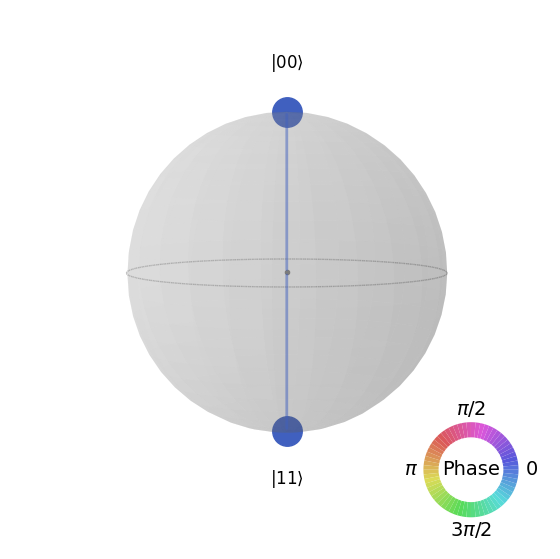

In [12]:
# Plot the Q-Sphere (The size of the nodes represents probability, color represents phase)
# You will clearly see the state is split perfectly between |00> and |11>
plot_state_qsphere(state)